# Environment Setup

In [ ]:
# set up environment
from os import path
from google.colab import drive

if not path.isdir('/content/drive'):
    drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/UA92/12 Applied Artificial Intelligence/Assignment dataset/adverts.csv")

In [ ]:
# environment settings

# performance settings
render_plots: bool = 1 # if True, will massively reduce performance
run_slow_models: bool = 0

# Initial data analysis

In [ ]:
# initial dataset copy
df_initial = df.__deepcopy__()

In [ ]:
# df_initial.head()

In [ ]:
# df_initial.info()

In [ ]:
# df_initial.describe()

In [ ]:
if render_plots:
    # correlation map
    plt.figure(figsize=(8, 1.5))
    plt.title('numeric correlation heatmap')
    sns.heatmap(
        data=df_initial.select_dtypes('number').corr(),
        cmap='coolwarm',
        annot=True
    )
    plt.show()

    plt.figure(figsize=(36,4))
    plt.title("price by reg_code")
    data = df_initial[['reg_code', 'price']].__deepcopy__()
    data['price'] = data['price'].astype(np.uint32)
    data['reg_code'] = data['reg_code'].astype('category').sort_values()
    sns.barplot(
        data=data,
        x='reg_code',
        y='price'
    )
    plt.grid()
    plt.show()

    plt.figure(figsize=(18,4))
    plt.title("price by fuel_type")
    sns.barplot(
        data=df_initial,
        x='fuel_type',
        y='price'
    )
    plt.grid()
    plt.show()

    plt.figure(figsize=(24,4))
    plt.title("price by standard_colour")
    sns.barplot(
        data=df_initial,
        x='standard_colour',
        y='price'
    )
    plt.grid()
    plt.show()

In [ ]:
columns = df_initial[['mileage', 'year_of_registration', 'price']].columns
distributions = pd.DataFrame(index=['mean', 'median', 'mode', 'std', 'skew'], columns=columns)

# Gemini
for col in columns:
    distributions.loc['mean', col] = df_initial[col].mean()
    distributions.loc['median', col] = df_initial[col].median()

    mode_val = df_initial[col].mode()
    distributions.loc['mode', col] = mode_val.iloc[0]

    distributions.loc['std', col] = df_initial[col].std()
    distributions.loc['skew', col] = df_initial[col].skew()

display(distributions)

,mileage,year_of_registration,price
mean,37743.595656,2015.006206,17341.965799
median,28629.5,2016.0,12600.0
mode,0.0,2017.0,8995
std,34831.724018,7.962667,46437.460951
skew,1.451132,-87.909954,154.681527


## Description
- Semantics
    - `public_reference` likely refers to some kind of reference number.
    - `mileage` refers to a vehicle's odometer reading.
    - `reg_code` could be associated with a vehicle's registration number (number plate).
    - `standard_colour`, `standard_make`, `standard_model` refer to the colour, manufacturer, and model of a vehicle.
    - `vehicle_condition` refers to the cosmetic and working conditions of a vehicle.
    - `year_of_registration` refers to the year on which a car was registered with a vehicle licensing authority.
    - `price` refers to the market or retail price of a vehicle.
    - `body_type` refers to the type/category of a vehicle.
    - `crossover_car_and_van` may refer to a vehicle being categorised as a mix between a car and van.
    - `fuel_type` refers to what kind of fuel a vehicle takes.
- Observed Data Types
    - At first, there are 7 columns with type 'object' (`np.dtypes.ObjectDType`), which is indescriptive, and should be converted where possible.
    - `public_reference: int` - integer type suggests quantitative data
    - `mileage: float | NaN` - quantitative
    - `reg_code: str | float | NaN` - qualitative
    - `standard_colour, standard_make, standard_model: str` - qualitative
    - `vehicle_condition: str = "NEW" | "USED"` binary classification, could be converted to bool - qualitative
    - `year_of_registration: float | NaN` - quantitative
    - `price: int` - quantitative
    - `body_type: str | NaN` - qualitative
    - `crossover_car_and_van: bool` - qualitative
    - `fuel_type: str | NaN` - qualitative
- Corrections
    - `vehicle_condition` refers to whether a vehicle is used or not.
    - `public_reference` doesn't seem to hold any significance as quantitative data, thus should be qualitative.
- Predictors (From most to least confident)
    - `mileage` should be inversely proportional to price.
    - `vehicle_condition` - on average, a new car should be more expensive than a used one.
    - `standard_model` - certain vehicle models should be worth more.
    - `standard_make` - some manufacturers make more expensive vehicles.
    - `year_of_registration` should be proportional to price, with some caveats ("classic" cars will be more valuable and likely appreciate in value over time).
    - some `body_type`s may be worth more than others.
    - vehicles with some `fuel_type`s may be worth more than others.
- Numerical analysis
    - There are many outliers in the numerical columns of the dataset, most notably in the `year_of_registration` column, with a minimum value of 999, indicating data error (The first automobile was created in 1885), and many modern cars in the 0.1 percentile (1983) or lower. This dataset doesn't seem to include vehicles created before the 21st century or late 20th century.
    - The dataset doesn't have any information on what units each value was measured in, going forward, we'll assume miles for `mileage` and GBP for `price`.
    - The `mileage` maximum value of 999,999 could represent a maximum 6-digit odometer reading, and the true mileage could be higher.
    - There are vehicles with:
        - `(vehicle_condition = "USED") && (mileage == 0)` indicating an odometer overflow or data error.
        - `(vehicle_condition = "NEW") && (0 < mileage <= 100)`.
        - `(vehicle_condition = "USED") && (0 < mileage <= 100)`.
        - We can assume that retailers will have a margin of acceptance for a "new" car, and `mileage` <= 100 miles seems like an appropriate margin. If this margin rule is applied to all the data, then `vehicle_condition` becomes redundant. Otherwise, depending on specific business rules on how a car is categorised as new or used, the data will contain inconsistencies.
- Importance
    - `public_reference` is likely unimportant, so it will be dropped.
    - due to reasons mentioned beforehand, `vehicle_condition` will be dropped.
    - `mileage` and `year_of_registration` will be key predictors of price.
    - The `standard_model` of a vehicle will likely be strongly proportional to it's price.

# Data handling

## Reworking columns

In [ ]:
# data cleanup
if 'public_reference' in df.columns:
    df = df.drop('public_reference', axis=1)

# if 'vehicle_condition' in df.columns:
#     df['vehicle_condition'] = df['vehicle_condition'].map({
#         "USED": 1,
#         "NEW": 0
#     }).astype(np.bool)
#     df.rename(inplace=True, columns={'vehicle_condition': 'used_vehicle'})

# There are inconsistencies with how this data labels vehicle_condition and mileage,
# so we'll drop the column.
df = df[~((df['mileage'] == 0) & (df['vehicle_condition'] == "USED"))]
if 'vehicle_condition' in df.columns:
    df = df.drop('vehicle_condition', axis=1)

## Removing missing data

In [ ]:
# missing data handling
for subset in ['mileage', 'reg_code', 'standard_colour', 'body_type', 'fuel_type']:
    df = df.dropna(subset=subset)
df['year_of_registration'] = df['year_of_registration'].fillna(df['year_of_registration'].median())

## Memory optimisation

In [ ]:
# data type memory optimisation
print(f"memory usage before optimisation: {(df.memory_usage().sum() / 1024 ** 2).round(2):,} MB")
df['reg_code'] = df['reg_code'].astype('category')
df['mileage'] = df['mileage'].astype(np.uint32)
df['standard_colour'] = df['standard_colour'].astype('category')
df['standard_make'] = df['standard_make'].astype('category')
df['standard_model'] = df['standard_model'].astype('category')
df['year_of_registration'] = df['year_of_registration'].astype(np.uint16)
df['price'] = df['price'].astype(np.uint32)
df['body_type'] = df['body_type'].astype('category')
df['fuel_type'] = df['fuel_type'].astype('category')
print(f"memory usage after optimisation: {(df.memory_usage().sum() / 1024 ** 2).round(2):,} MB")

memory usage before optimisation: 28.15 MB
memory usage after optimisation: 9.09 MB


In [ ]:
# convert year_of_registration into vehicle_age to reduce domain and memory usage by converting to uint8
from datetime import datetime

if 'year_of_registration' in df.columns:
    df['year_of_registration'] = datetime.now().year - df['year_of_registration']
    df.rename(inplace=True, columns={'year_of_registration': 'vehicle_age'})

    df['vehicle_age'] = df['vehicle_age'].astype(np.uint8)

## Removing outliers & errors

In [ ]:
# remove outliers
for subset in df.select_dtypes('number'):
    iqr = df[subset].quantile(0.75) - df[subset].quantile(0.25)
    min_value = df[subset].quantile(0.25) - 1.5 * iqr
    max_value = df[subset].quantile(0.75) + 1.5 * iqr
    df = df[(df[subset] > min_value) & (df[subset] < max_value)]

# remove erroneous values (data error, odometer overflow, etc.)
if 'used_vehicle' in df.columns:
    df = df[~((df['mileage'] == 0) & (df['used_vehicle'] == True))]
df['reg_code'] = df['reg_code'].astype('string').astype('category') # remove empty reg_code categories

In [ ]:
df_pre_encode = df.__deepcopy__()

## Encoding data

In [ ]:
# encode data using target encoding
for subset in ['reg_code', 'standard_colour', 'standard_make', 'standard_model', 'body_type', 'fuel_type']:
    means = df.groupby(subset, observed=False)["price"].mean()
    df[str(subset + "_te")] = df[subset].map(means).astype(np.uint16) # high precision not required (has negligible effect on models), so using uint16 instead of float64
    df = df.drop(subset, axis=1)

## Plots

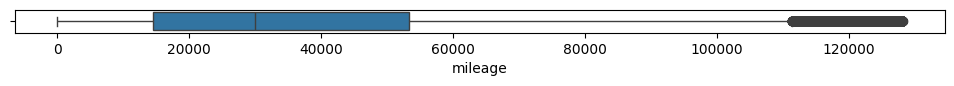

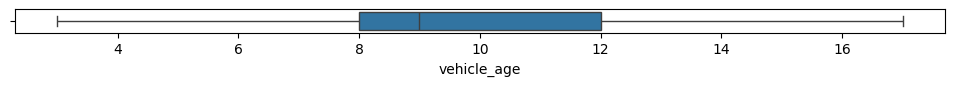

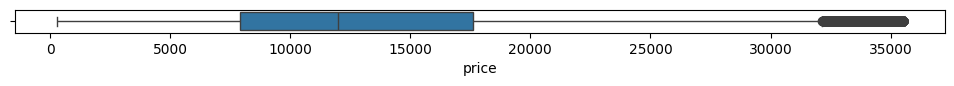

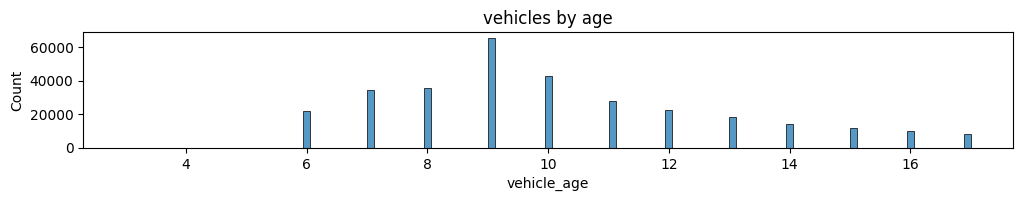

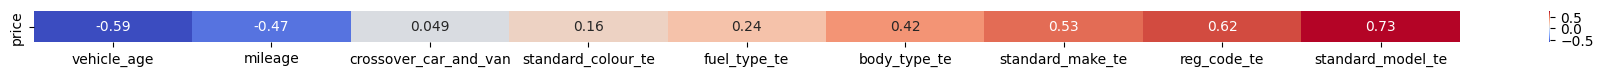

In [ ]:
if render_plots:
    for subset in df[['mileage', 'vehicle_age', 'price']]:
        plt.figure(figsize=(12,0.3))
        sns.boxplot(
            data=df,
            x=subset
        )
        plt.show()

    plt.figure(figsize=(12,1.5))
    plt.title("vehicles by age")
    sns.histplot(
        data=df['vehicle_age'],
    )
    plt.show()

    corr = df.corr(numeric_only=True)["price"].drop("price").sort_values() # ChatGPT
    corr = corr.to_frame().T # ChatGPT
    plt.figure(figsize=(23, 0.4))
    sns.heatmap(
        data=corr,
        annot=True,
        cmap='coolwarm'
    )
    plt.show()

In [ ]:
# df.describe()

In [ ]:
# df.info()

In [ ]:
# df.sample(5)

# Machine learning

## Model Setup

In [ ]:
import sklearn as skl

RANDOM_STATE_SEED = 47

X = df.drop(columns=['price'])
y = df['price']
X_no_mileage = X.drop(columns=['mileage', 'crossover_car_and_van'])
X_no_age = X.drop(columns=['vehicle_age'])

In [ ]:
X_train_unscaled, X_test_unscaled, \
X_no_mileage_train, X_no_mileage_test, \
X_no_age_train, X_no_age_test, \
y_train, y_test \
= skl.model_selection.train_test_split(
    X, X_no_mileage, X_no_age, y,
    test_size=0.3,
    random_state=RANDOM_STATE_SEED
)

scaler = skl.preprocessing.StandardScaler()
# scaler = skl.preprocessing.MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)

In [ ]:
metrics = {}
def log_metrics() -> None:
    metrics[str(model)] = {
        'r²': f'{skl.metrics.r2_score(y_test, y_pred):.4f}',
        'mae': f'{skl.metrics.mean_absolute_error(y_test, y_pred):.4f}',
        'mse': f'{skl.metrics.mean_squared_error(y_test, y_pred):.4f}',
        'rmse': f'{skl.metrics.root_mean_squared_error(y_test, y_pred):.4f}'
    }

In [ ]:
def show_comparison() -> None:
    if render_plots:
        fig, axes = plt.subplots(
            1, 2,
            figsize=(16, 4)
        )

        sns.histplot(
            data=y_test,
            kde=True,
            ax=axes[0]
        )
        axes[0].set_title('expected prices')

        sns.histplot(
            data=y_pred,
            kde=True,
            ax=axes[1]
        )
        axes[1].set_title('predicted prices')
        axes[1].set(xlabel='price')
        plt.show()

        fig, ax = plt.subplots(figsize=(16, 4))
        sns.kdeplot(
            data=y_test,
            color='crimson',
            label='test data',
            fill=True
        )
        sns.kdeplot(
            data=y_pred,
            color='limegreen',
            label='predicted',
            fill=True
        )
        plt.legend()
        plt.show()

## Model 1 (Linear Regressor)

### Standard

In [ ]:
X_train, X_test = X_train_scaled, X_test_scaled

model = skl.linear_model.LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
show_comparison()

df_coef = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})
display(df_coef)

,feature,coefficient
0,mileage,-1671.086613
1,vehicle_age,735.735374
2,crossover_car_and_van,114.892753
3,reg_code_te,3347.952020
4,standard_colour_te,159.657588
5,standard_make_te,1278.844078
6,standard_model_te,3614.576097
7,body_type_te,367.202475
8,fuel_type_te,397.597372


As expected, the coefficient results show that as `mileage` goes up, price goes down, but as `vehicle_age` goes up, price also goes up, which contradicts the original hypothesis. The following cell attempts to investigate the correlation between `vehicle_age` and `price` at A. different intervals of `mileage`, and B. different values of mileage. Findings show that the correlation should be negative for most mileage subsets of the data, as originally hypothesised.

This suggests multicollinearity between `mileage` and `vehicle_age`

In [ ]:
if render_plots:
    def generate_vehicle_age_price_corr_report(range_params: tuple[int], *, show_ranges: bool) -> None:
        """generate a vehicle_age to price correlation report for specific mileage values

        Parameters:
        range_params -- parameters to be passed into the range(start, end, increment) of a for loop, the range of values chosen for mileage
        Keyword Parameters:
        show_ranges -- if True, generate report using mileage intervals instead of single values.
        """
        increment = range_params[2]
        data = df[['price', 'vehicle_age']].corr().iloc[0].iloc[[1]]

        for n in range(*range_params):
            if show_ranges:
                index = f'[{n}..{n+increment})'
                cur_mileage = df[(n <= df['mileage']) & (df['mileage'] < n+increment)]
            else:
                index = f'{n}'
                cur_mileage = df[df['mileage'] == n]
            data.loc[index] = cur_mileage[['price', 'vehicle_age']].corr().iloc[0].iloc[[1]].vehicle_age

        data = data.drop(index='vehicle_age')
        data.rename('price to vehicle_age correlation', inplace=True)
        display(data.mean())

        ax = plt.figure(figsize=(24,4))
        sns.barplot(
            data=data
        )
        plt.xlabel('mileage')
        plt.show()

    generate_vehicle_age_price_corr_report((0, df['mileage'].max(), 100), show_ranges=False)
    generate_vehicle_age_price_corr_report((0, df['mileage'].max(), 100), show_ranges=True)

### Exclude mileage feature

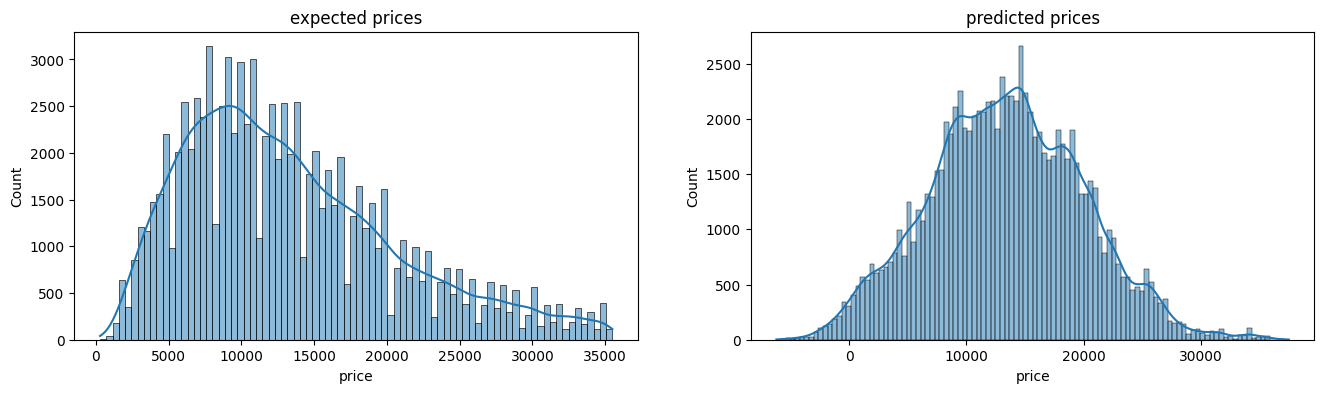

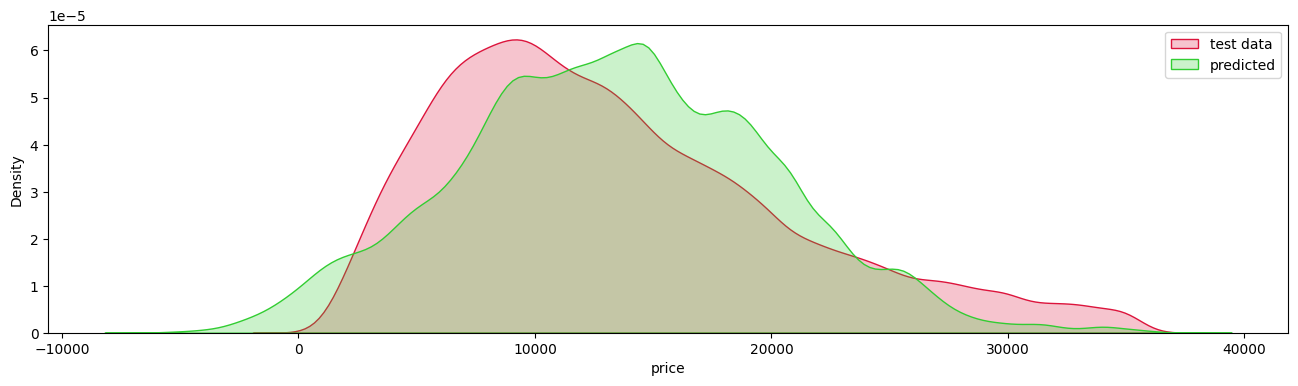

,feature,coefficient
0,vehicle_age,42.567755
1,reg_code_te,0.885752
2,standard_colour_te,0.092519
3,standard_make_te,0.309078
4,standard_model_te,0.667233
5,body_type_te,0.099465
6,fuel_type_te,0.101562


In [ ]:
X_train, X_test = X_no_mileage_train, X_no_mileage_test

model = skl.linear_model.LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
show_comparison()

df_coef = pd.DataFrame({
    'feature': X_no_mileage.columns,
    'coefficient': model.coef_
})
display(df_coef)

## Model 2 (Decision Tree Regressor)

In [ ]:
X_train = X_train_scaled
X_test = X_test_scaled

model = skl.tree.DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=RANDOM_STATE_SEED
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
log_metrics()
show_comparison()

## Model 3 (Random Forest Regressor)

In [ ]:
# SLOW (>60sec)
if run_slow_models:
    X_train = X_train_scaled
    X_test = X_test_scaled

    model = skl.ensemble.RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=RANDOM_STATE_SEED
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    plt.barh(
        X.columns,
        model.feature_importances_
    )

    log_metrics()
    show_comparison()

The graph above shows that it's actually the `reg_code` and `standard_model` parameters which are the most important, but of the quantitative parameters, vehicle age and mileage are the most important.

## Model Statistics

In [ ]:
# Error statistics
for model_name, model_metrics in metrics.items():
    print(model_name)
    for metric_name, metric_value in model_metrics.items():
        print(f'\t{metric_name:>4}: {metric_value:<5}')